In [8]:
import sys
import os

cwd = os.getcwd()
print(cwd)
project_root = os.path.abspath(os.path.join(cwd, "../../.."))
print(project_root)


/Users/macbookpro/Desktop/cpmpy/cpmpy/tools/explain
/Users/macbookpro/Desktop/cpmpy


In [9]:

sys.path.append(project_root)
sys.path.append(os.path.join(cwd, "XCP-explain"))


from visualize import *
from read_data import get_data
from factory import *
from cpmpy.tools.explain import marco
from cpmpy.tools.explain.utils import *
from cpmpy.tools.explain.visualize_diversity import *

instance = os.path.join("XCP-explain","Benchmarks/CustomInstance.txt")
data = get_data(instance)
factory = NurseSchedulingFactory(data)

/Users/macbookpro/Desktop/cpmpy/cpmpy/solvers/gurobi.py:46: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [10]:
data.staff[["name", "MaxShifts","MaxWeekends"]]

,name,MaxShifts,MaxWeekends
0,Megan,E=14|L=14,2
1,Katherine,E=14|L=14,1
2,Robert,E=14|L=14,2
3,Jonathan,E=14|L=0,1
4,William,E=0|L=14,2
5,Richard,E=14|L=14,2
6,Kristen,E=14|L=14,1
7,Kevin,E=14|L=14,2
8,Thomas,E=14|L=14,1


MUS 1: 

- Megan requests not to work shift L on Wed 1
- Katherine requests not to work shift L on Thu 1
- Katherine has a day off on Tue 1
- William should have at least 2 consecutive days off
- Robert has a day off on Wed 1
- William requests to work shift L on Sat 1
- None of ['E'] can follow shift L for Katherine
- William can work at most 5 days before having a day off
- Katherine should work at least 2 days before having a day off
- William requests to work shift L on Mon 2
- William should have at least 2 consecutive days off
- Jonathan can work at most 0 L-shifts
- Shift L on Wed 1 must be covered by 5 nurses out of 9
- William requests to work shift L on Thu 1
MUS 2: 

- Megan requests not to work shift L on Wed 1
- None of ['E'] can follow shift L for Richard
- Shift L on Sat 2 must be covered by 3 nurses out of 9
- None of ['E'] can follow shift L for Thomas
- William can work at most 5 days before having a day off
- Megan requests to work shift L on Wed 2
- Kristen should w

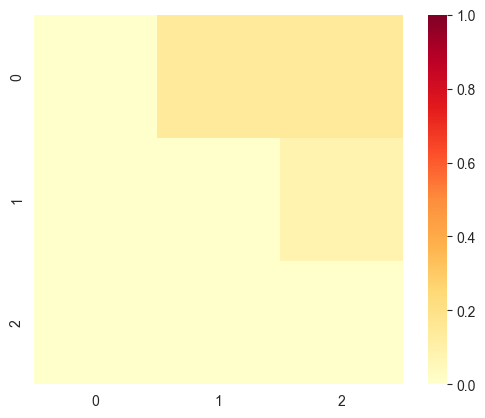

In [11]:
# enumerate 3 MUSes of the nurse rostering example 
model, nurse_view = factory.get_decision_model()
result = []
for i, (kind, subset) in enumerate(marco(model.constraints, solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    print(f"MUS {i+1}: \n")
    for c in subset:
        print("-", c)
    if i == 2:
        break


div_matrix = diversity_matrix(result, "overlap")
print(div_matrix)
visualize_heatmap(div_matrix)
# sometimes these give very different MUSes, but sometimes very similar


In [12]:

avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of the first {len(result)} MUSes generated by MARCO is: {avg}")

The average diversity of the first 3 MUSes generated by MARCO is: 0.12369337979094079
